In [18]:
SEED = 42
import numpy as np
np.random.seed(SEED)
from pathlib import Path
import pandas as pd
import os

print("Current working directory:", os.getcwd())

COLUMNS = (
    ["engine_id", "cycle"]
    + [f"op{i}" for i in range(1, 4)]
    + [f"s{i}" for i in range(1, 22)]
)

DATA_PATHS = [
    Path("data/raw"),
    Path("../data/raw"),
    Path("../../data/raw")
]

DATA_DIR = None
for p in DATA_PATHS:
    if p.exists():
        DATA_DIR = p
        break

if DATA_DIR is None:
    raise FileNotFoundError("Could not locate data/raw directory")

def load_cmapss(file_path):
    df = pd.read_csv(file_path, sep=r"\s+", header=None)
    df = df.iloc[:, :len(COLUMNS)]
    df.columns = COLUMNS
    return df

def load_rul(file_path):
    rul = pd.read_csv(file_path, header=None, names=["RUL"])
    rul["engine_id"] = range(1, len(rul)+1)
    return rul[["engine_id","RUL"]]

train_df = load_cmapss(DATA_DIR / "train_FD001.txt")
test_df = load_cmapss(DATA_DIR / "test_FD001.txt")
rul_df = load_rul(DATA_DIR / "RUL_FD001.txt")

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("RUL:", rul_df.shape)


Current working directory: c:\Users\Ishaan Nandoskar\Downloads\nasa_gan_turbo_fan_engine\notebooks
Train: (20631, 26)
Test: (13096, 26)
RUL: (100, 2)


In [19]:

print(train_df.shape)
print(test_df.shape)

print("\nMissing Values")
print(train_df.isnull().sum().sum())

print("\nDuplicate Rows")
print(train_df.duplicated().sum())

print("\nNumber of Engines")
print(train_df["engine_id"].nunique())

(20631, 26)
(13096, 26)

Missing Values
0

Duplicate Rows
0

Number of Engines
100


In [20]:
engine_life = (
    train_df.groupby("engine_id")["cycle"]
    .max()
    .reset_index()
)

engine_life.columns = ["engine_id", "max_cycle"]

In [21]:
engine_life.describe()

,engine_id,max_cycle
count,100.000000,100.000000
mean,50.500000,206.310000
std,29.011492,46.342749
min,1.000000,128.000000
25%,25.750000,177.000000
50%,50.500000,199.000000
75%,75.250000,229.250000
max,100.000000,362.000000


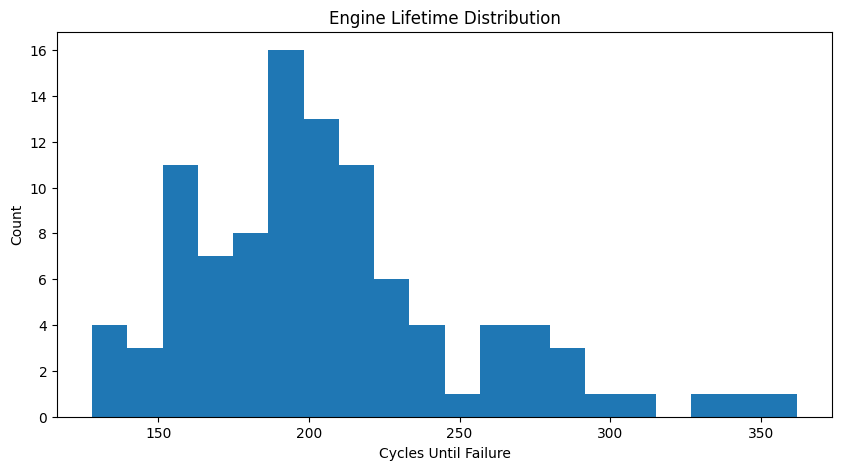

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(engine_life["max_cycle"], bins=20)
plt.xlabel("Cycles Until Failure")
plt.ylabel("Count")
plt.title("Engine Lifetime Distribution")
plt.show()

In [23]:
max_cycles = (
    train_df.groupby("engine_id")["cycle"]
    .max()
)

train_df["RUL"] = (
    train_df["engine_id"]
    .map(max_cycles)
    - train_df["cycle"]
)

In [24]:
train_df.groupby("engine_id")["RUL"].min().head()

engine_id
1    0
2    0
3    0
4    0
5    0
Name: RUL, dtype: int64

In [25]:
train_df["RUL"].max()

np.int64(361)

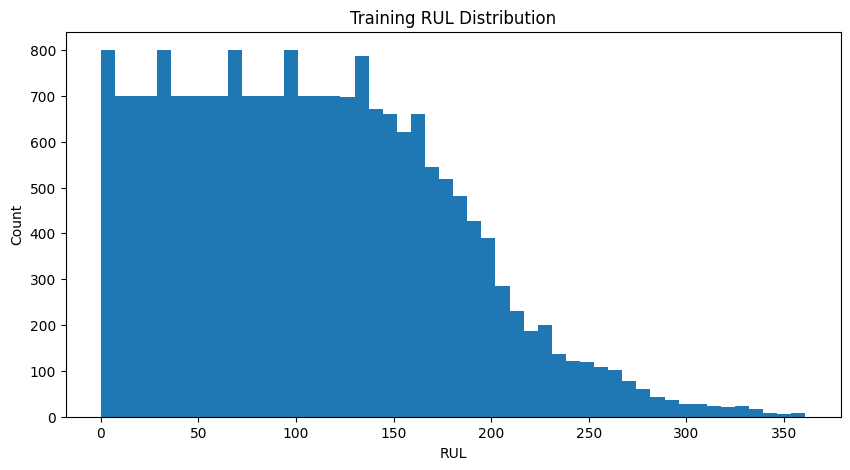

In [26]:
plt.figure(figsize=(10,5))
plt.hist(train_df["RUL"], bins=50)
plt.xlabel("RUL")
plt.ylabel("Count")
plt.title("Training RUL Distribution")
plt.show()

In [27]:
from pathlib import Path

output_dir = DATA_DIR.parent / "processed" / "FD001"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_file = output_dir / "train_with_rul.csv"

train_df.to_csv(
    output_file,
    index=False
)

print(f"Saved successfully to:\n{output_file.resolve()}")

Saved successfully to:
C:\Users\Ishaan Nandoskar\Downloads\nasa_gan_turbo_fan_engine\data\processed\FD001\train_with_rul.csv


In [28]:
sensor_cols = [f"s{i}" for i in range(1, 22)]

variance_df = pd.DataFrame({
    "sensor": sensor_cols,
    "variance": train_df[sensor_cols].var()
}).sort_values("variance")

variance_df

,sensor,variance
s1,s1,0.000000e+00
s10,s10,0.000000e+00
s19,s19,0.000000e+00
s18,s18,0.000000e+00
s16,s16,1.926023e-34
s5,s5,3.155597e-30
s6,s6,1.929279e-06
s15,s15,1.406628e-03
s8,s8,5.038938e-03
s13,s13,5.172330e-03


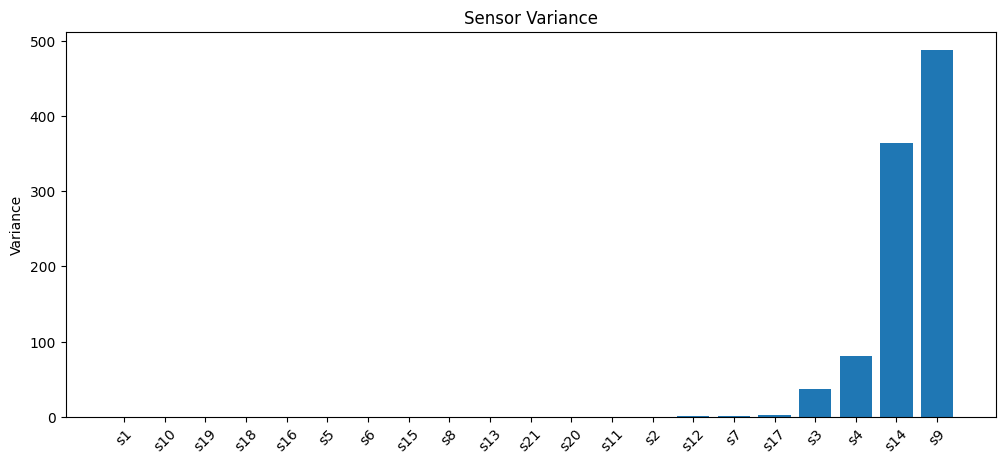

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    variance_df["sensor"],
    variance_df["variance"]
)

plt.xticks(rotation=45)
plt.title("Sensor Variance")
plt.ylabel("Variance")
plt.show()